# Analisando Imagens com o Google Gemini API

Neste notebook, vamos enviar imagens locais (da pasta `imagens`) para a API do Google Gemini utilizando o novo SDK oficial em Python: `google-genai`.

Certifique-se de ter configurado a sua chava de API na variável de ambiente `GEMINI_API_KEY`.

In [2]:
import os
from dotenv import load_dotenv

# Carrega as variáveis de ambiente do arquivo .env, se existir
load_dotenv()

api_key = os.getenv("GEMINI_API_KEY")
if not api_key:
    print("AVISO: Por favor, crie um arquivo .env com a sua GEMINI_API_KEY, ou defina-a no sistema.")

## 1. Carregar a Imagem

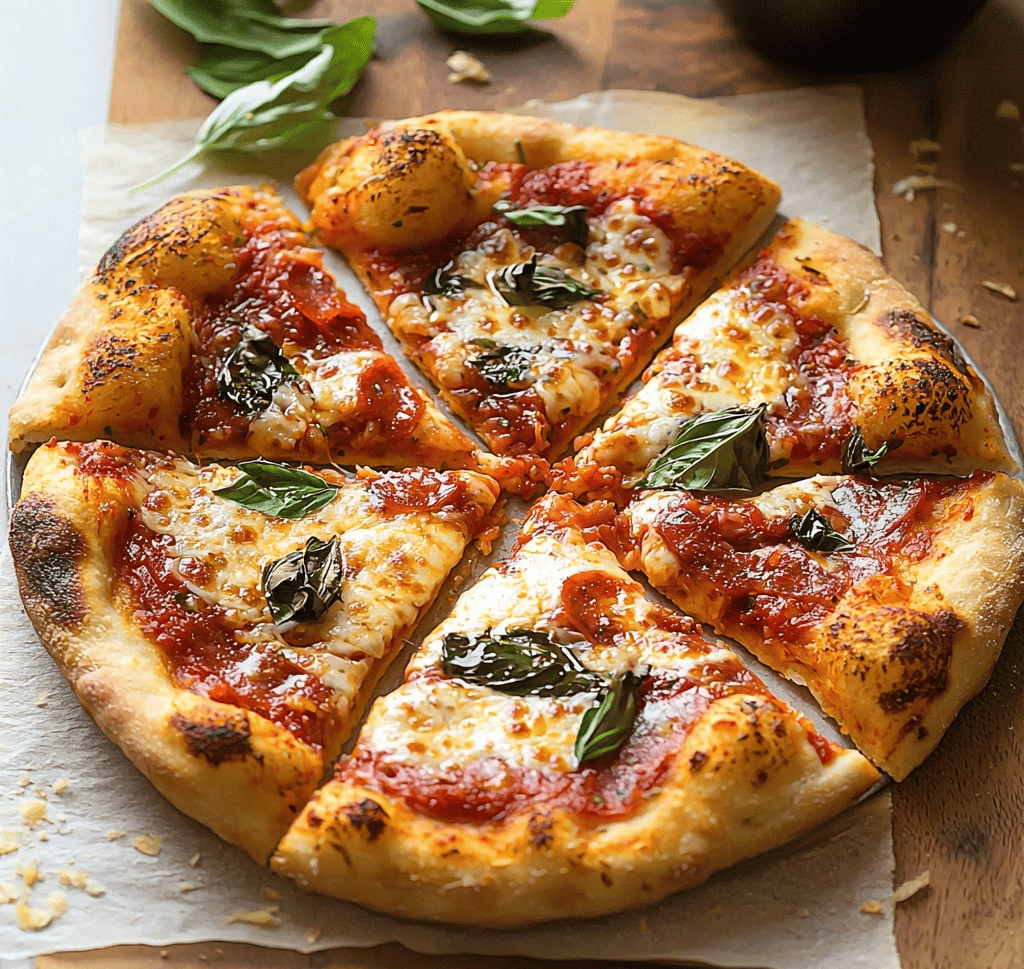

In [3]:
from PIL import Image

# Caminho para a pasta onde estão nossas imagens
# Você pode alterar para 'cats_dog.png', 'kitchen.png' ou 'pizza.png'
image_path = os.path.join("imagens", "pizza.png") 

# Carrega a imagem com a biblioteca Pillow
try:
    image = Image.open(image_path)
    # Utilizando o recurso do Jupyter para exibir a imagem nativamente
    display(image)  
except FileNotFoundError:
    print(f"Imagem não encontrada: {image_path}")

## 2. Enviar a Imagem para o Gemini
Agora vamos inicializar o cliente da API e enviar a imagem junto com um prompt de texto.

In [7]:
from google import genai
from google.genai import types
from pydantic import BaseModel, Field

# Inicializa o cliente do Gemini API (novo SDK)
client = genai.Client(api_key=api_key)

# Modelo recomendado para processar imagens e texto (multimodal)
model_id = "gemini-2.5-flash"

# Definimos a nossa pergunta (prompt)
prompt = "Descreva esta imagem com o máximo de detalhes possível, focando nos objetos principais, cores e no ambiente."

# Estrutura de saída esperada (Output Estruturado)
class DescricaoImagem(BaseModel):
    objetos_principais: list[str] = Field(description="Lista dos objetos principais encontrados na imagem")
    cores_predominantes: list[str] = Field(description="A paleta de cores ou as cores que mais se destacam")
    ambiente: str = Field(description="O ambiente, local ou contexto onde a cena ocorre")
    descricao_detalhada: str = Field(description="Descrição detalhada e abrangente da imagem")

print(f"Enviando a imagem para o Gemini (modelo: {model_id})... Aguarde.\n")

try:
    # Chamada para a API com o novo SDK configurado para output estruturado
    response = client.models.generate_content(
        model=model_id,
        contents=[
            image, 
            prompt
        ],
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=DescricaoImagem,
            temperature=0.2, # Baixa temperatura para dados mais objetivos
        )
    )

    print("=== Resposta do Gemini (JSON Estruturado) ===")
    print(response.text)
    
except Exception as e:
    print("Ocorreu um erro ao chamar a API:\n", e)

Enviando a imagem para o Gemini (modelo: gemini-2.5-flash)... Aguarde.

=== Resposta do Gemini (JSON Estruturado) ===
{"objetos_principais": ["pizza", "fatias de pizza", "manjeric\r\n\r\nc\r\n\r\no", "molho de tomate", "queijo mussarela", "t\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\